# Marketing Funnel & Conversion Performance Analysis

## Project Objective

This project analyzes marketing campaign data from a Portuguese banking institution to understand customer conversion behavior and identify opportunities to improve marketing performance.

The analysis focuses on:
- Lead-to-customer conversion rates
- Funnel drop-off analysis
- Customer segment performance
- Campaign effectiveness
- Actionable business recommendations

In [4]:
#import libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns",None)

## Load Dataset

In [5]:
df = pd.read_csv("../Dataset/bank-full.csv",sep=";")
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


In [8]:
df.shape

(45211, 17)

## Data Audit

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        45211 non-null  int64 
 1   job        45211 non-null  object
 2   marital    45211 non-null  object
 3   education  45211 non-null  object
 4   default    45211 non-null  object
 5   balance    45211 non-null  int64 
 6   housing    45211 non-null  object
 7   loan       45211 non-null  object
 8   contact    45211 non-null  object
 9   day        45211 non-null  int64 
 10  month      45211 non-null  object
 11  duration   45211 non-null  int64 
 12  campaign   45211 non-null  int64 
 13  pdays      45211 non-null  int64 
 14  previous   45211 non-null  int64 
 15  poutcome   45211 non-null  object
 16  y          45211 non-null  object
dtypes: int64(7), object(10)
memory usage: 5.9+ MB


In [12]:
df.isnull().sum()

age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
y            0
dtype: int64

In [14]:
df.describe()

,age,balance,day,duration,campaign,pdays,previous
count,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000
mean,40.936210,1362.272058,15.806419,258.163080,2.763841,40.197828,0.580323
std,10.618762,3044.765829,8.322476,257.527812,3.098021,100.128746,2.303441
min,18.000000,-8019.000000,1.000000,0.000000,1.000000,-1.000000,0.000000
25%,33.000000,72.000000,8.000000,103.000000,1.000000,-1.000000,0.000000
50%,39.000000,448.000000,16.000000,180.000000,2.000000,-1.000000,0.000000
75%,48.000000,1428.000000,21.000000,319.000000,3.000000,-1.000000,0.000000
max,95.000000,102127.000000,31.000000,4918.000000,63.000000,871.000000,275.000000


In [16]:
df.duplicated().sum()

0

### Data Audit Summary

- Dataset contains 45,211 records and 17 features.
- No missing values were found in the dataset.
- Data includes customer demographics, campaign information, and subscription outcomes.
- Duplicate records were checked before analysis.

## Data Cleaning

In [18]:
df_clean = df.copy()
df_clean.shape

(45211, 17)

In [20]:
df_clean.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


In [124]:
df_clean.to_csv("../outputs/bank_marketing_cleaned.csv",index=False)
print("File saved successfully")

File saved successfully


### Data Cleaning Summary

- No missing values were found.
- No duplicate records were found.
- Dataset was copied into a cleaned version for further analysis.
- Data is ready for funnel and conversion analysis.

## Funnel Metrics Analysis

In [114]:
total_leads = len(df_clean)
converted_customers = len(df_clean[df_clean['y'] == 'yes'])
not_converted = len(df_clean[df_clean['y'] == 'no'])

conversion_rate = (converted_customers/total_leads) * 100
drop_off_rate = (not_converted/total_leads) * 100

print("---------Funnel Metrics Analysis----------")
print("Total Leads:", total_leads)
print("Converted Customers:",converted_customers)
print("Not converted:",not_converted)
print("Conversion Rate (%) :",round(conversion_rate,2))
print("Drop-Off Rate (%) :",round(drop_off_rate,2))


---------Funnel Metrics Analysis----------
Total Leads: 45211
Converted Customers: 5289
Not converted: 39922
Conversion Rate (%) : 11.7
Drop-Off Rate (%) : 88.3


In [24]:
funnel_summary = pd.DataFrame( {
    "Stage":["Total Leads","Converted Customers","Dropped Customers"],
    "Count":[total_leads,converted_customers,not_converted]
})
funnel_summary

,Stage,Count
0,Total Leads,45211
1,Converted Customers,5289
2,Dropped Customers,39922


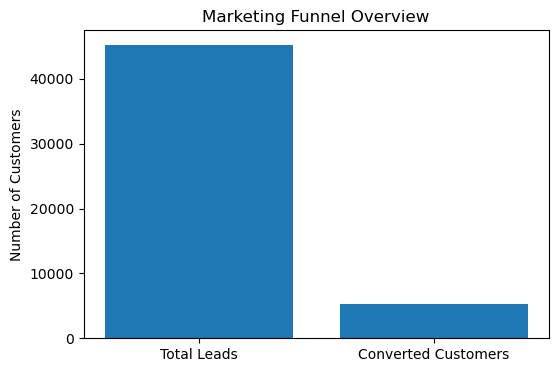

In [122]:
stages=["Total Leads","Converted Customers"]
values = [45211,5289]

plt.figure(figsize= (6,4))
plt.bar(stages, values)

plt.title("Marketing Funnel Overview")
plt.ylabel("Number of Customers")

plt.show()


### Funnel Metrics Interpretation

- Total Leads represent all customers contacted during marketing campaigns.
- Converted Customers represent customers who subscribed to the term deposit.
- Dropped Customers represent customers who did not subscribe.
- Conversion Rate measures the effectiveness of the marketing campaign.
- Drop-Off Rate highlights potential opportunities for funnel optimization.

## Customer Conversion Analysis

In [26]:
conversion_by_job = (
    df_clean.groupby('job')['y'].apply(lambda x: (x == 'yes').mean() * 100).sort_values(ascending=False)
)
conversion_by_job.head(10)

job
student          28.678038
retired          22.791519
unemployed       15.502686
management       13.755551
admin.           12.202669
self-employed    11.842939
unknown          11.805556
technician       11.056996
services          8.883004
housemaid         8.790323
Name: y, dtype: float64

In [32]:
conversion_by_education = (
    df_clean.groupby('education')['y'].apply(lambda x: (x == 'yes').mean() * 100).sort_values(ascending=False)
)
conversion_by_education


education
tertiary     15.006390
unknown      13.570275
secondary    10.559435
primary       8.626478
Name: y, dtype: float64

In [30]:
conversion_by_marital = (
    df_clean.groupby('marital')['y'].apply(lambda x: (x == 'yes').mean() * 100).sort_values(ascending=False)
)
conversion_by_marital

marital
single      14.949179
divorced    11.945458
married     10.123466
Name: y, dtype: float64

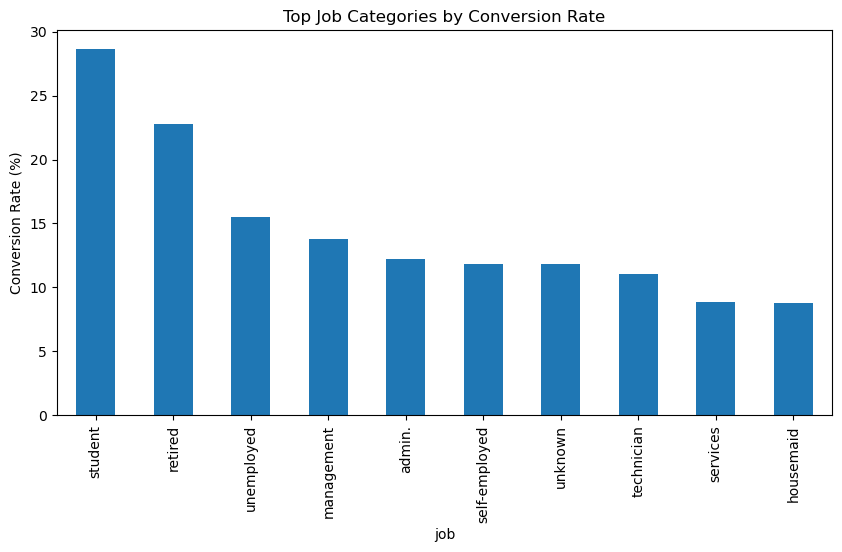

In [40]:
plt.figure(figsize=(10,5))

conversion_by_job.head(10).plot(kind='bar')
plt.title("Top Job Categories by Conversion Rate")
plt.ylabel("Conversion Rate (%)")
plt.show()

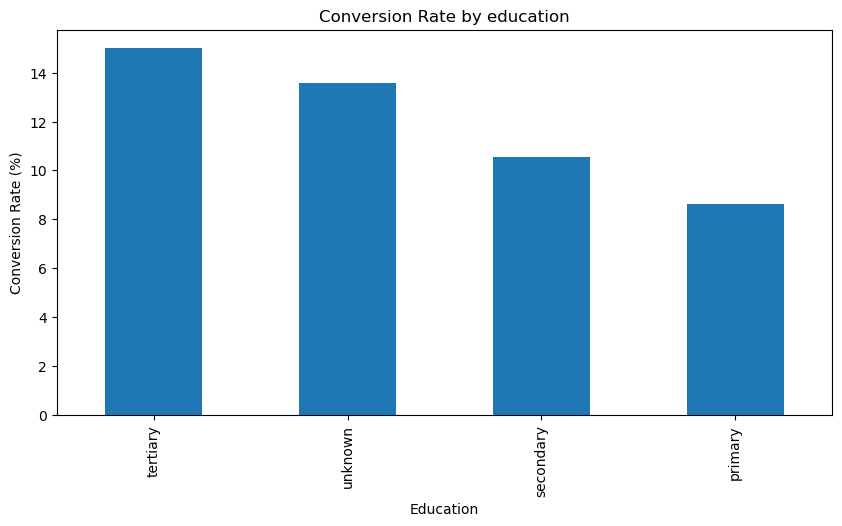

In [58]:
plt.figure(figsize=(10,5))

conversion_by_education.plot(kind='bar')
plt.title("Conversion Rate by education")
plt.ylabel("Conversion Rate (%)")
plt.xlabel("Education")
plt.show()

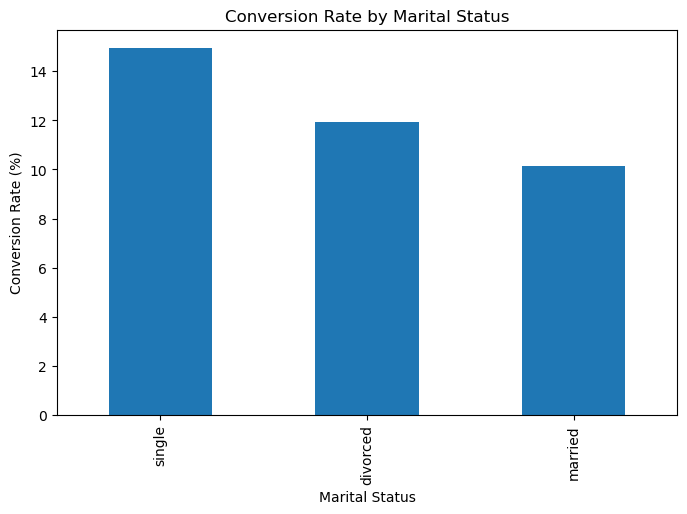

In [72]:
plt.figure(figsize=(8,5))

conversion_by_marital.plot(kind='bar')
plt.title("Conversion Rate by Marital Status")
plt.ylabel("Conversion Rate (%)")
plt.xlabel("Marital Status")
plt.show()

## Campaign Performance Analysis

### Conversion by Contact Method

In [45]:
conversion_by_contact = (
    df_clean.groupby('contact')['y'].apply(lambda x: (x == 'yes').mean() * 100).sort_values(ascending=False)
)
conversion_by_contact

contact
cellular     14.918900
telephone    13.420509
unknown       4.070661
Name: y, dtype: float64

### Conversion by Month

In [48]:
conversion_by_month = (
    df_clean.groupby('month')['y'].apply(lambda x: (x == 'yes').mean() * 100).sort_values(ascending=False)
)
conversion_by_month

month
mar    51.991614
dec    46.728972
sep    46.459413
oct    43.766938
apr    19.679400
feb    16.647792
aug    11.013286
jun    10.222805
nov    10.151134
jan    10.121169
jul     9.093546
may     6.719454
Name: y, dtype: float64

### Conversion by Housing Loan

In [52]:
conversion_by_housing = (
    df_clean.groupby('housing')['y'].apply(lambda x: (x == 'yes').mean() * 100).sort_values(ascending=False)
)
conversion_by_housing

housing
no     16.702355
yes     7.699960
Name: y, dtype: float64

### Conversion by Personal Loan

In [54]:
conversion_by_loan = (
    df_clean.groupby('loan')['y'].apply(lambda x: (x == 'yes').mean() * 100).sort_values(ascending=False)
)
conversion_by_loan

loan
no     12.655727
yes     6.681391
Name: y, dtype: float64

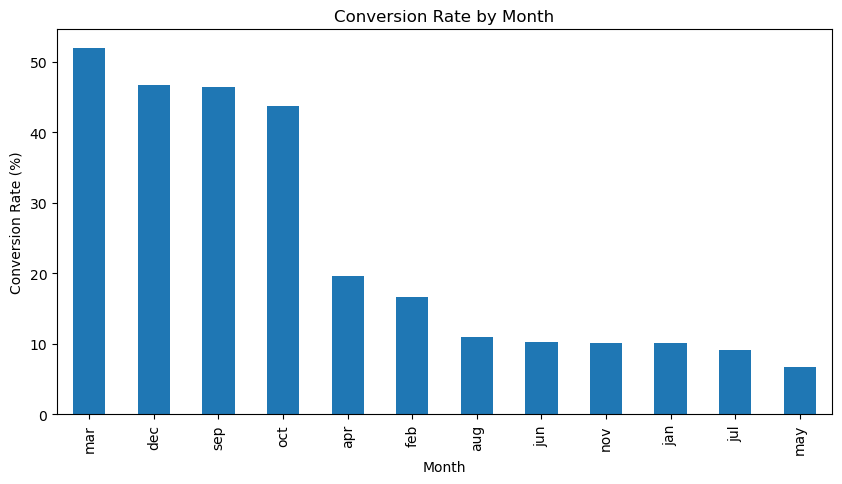

In [56]:
plt.figure(figsize=(10,5))

conversion_by_month.plot(kind='bar')
plt.title("Conversion Rate by Month")
plt.ylabel("Conversion Rate (%)")
plt.xlabel("Month")
plt.show()

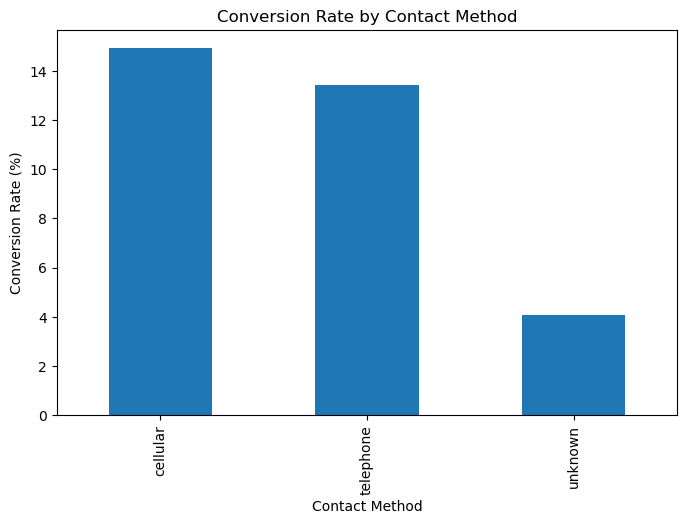

In [70]:
plt.figure(figsize=(8,5))

conversion_by_contact.plot(kind='bar')
plt.title("Conversion Rate by Contact Method")
plt.ylabel("Conversion Rate (%)")
plt.xlabel("Contact Method")
plt.show()

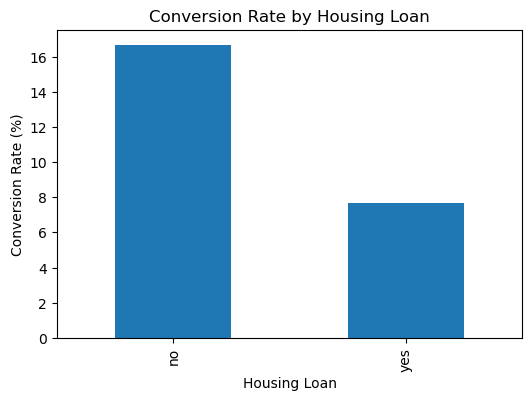

In [80]:
plt.figure(figsize=(6,4))

conversion_by_housing.plot(kind='bar')
plt.title("Conversion Rate by Housing Loan")
plt.ylabel("Conversion Rate (%)")
plt.xlabel("Housing Loan")
plt.show()

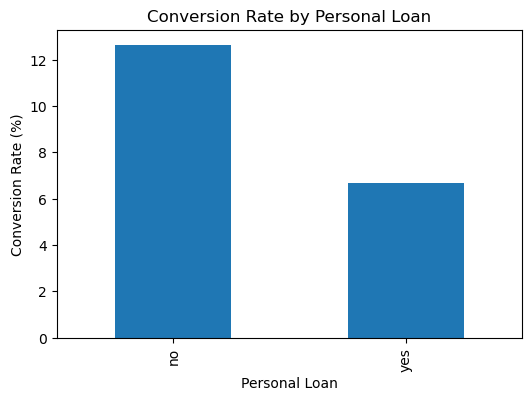

In [82]:
plt.figure(figsize=(6,4))

conversion_by_loan.plot(kind='bar')
plt.title("Conversion Rate by Personal Loan")
plt.ylabel("Conversion Rate (%)")
plt.xlabel("Personal Loan")
plt.show()

### Previous Campaign Outcome Analysis

In [85]:
conversion_by_poutcome = (
    df_clean.groupby('poutcome')['y'].apply(lambda x: (x == 'yes').mean() * 100).sort_values(ascending=False)
)
conversion_by_poutcome

poutcome
success    64.725347
other      16.684783
failure    12.609671
unknown     9.161503
Name: y, dtype: float64

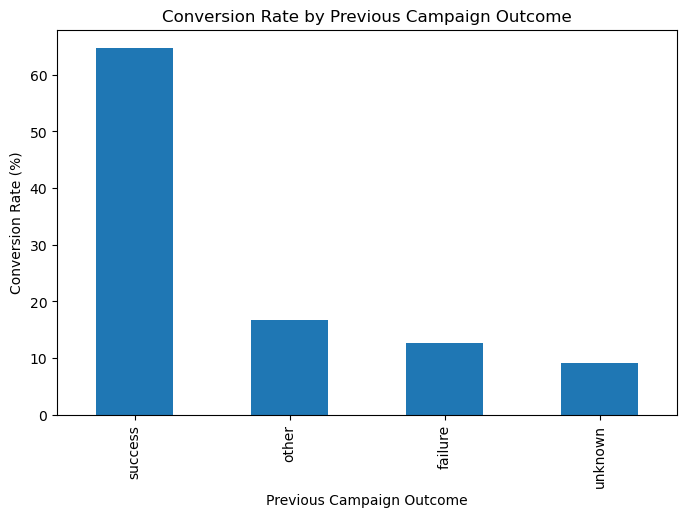

In [87]:
plt.figure(figsize=(8,5))

conversion_by_poutcome.plot(kind='bar')
plt.title("Conversion Rate by Previous Campaign Outcome")
plt.ylabel("Conversion Rate (%)")
plt.xlabel("Previous Campaign Outcome")
plt.show()

## Campaign Contact Frequency Analysis

### Conversion Rate by Number of Contacts

In [100]:
campaign_analysis = (
    df_clean.groupby('campaign')['y'].apply(lambda x: (x == 'yes').mean() * 100)
)
campaign_analysis.head(15)

campaign
1     14.597583
2     11.203519
3     11.193624
4      9.000568
5      7.879819
6      7.126259
7      6.394558
8      5.925926
9      6.422018
10     5.263158
11     7.960199
12     2.580645
13     4.511278
14     4.301075
15     4.761905
Name: y, dtype: float64

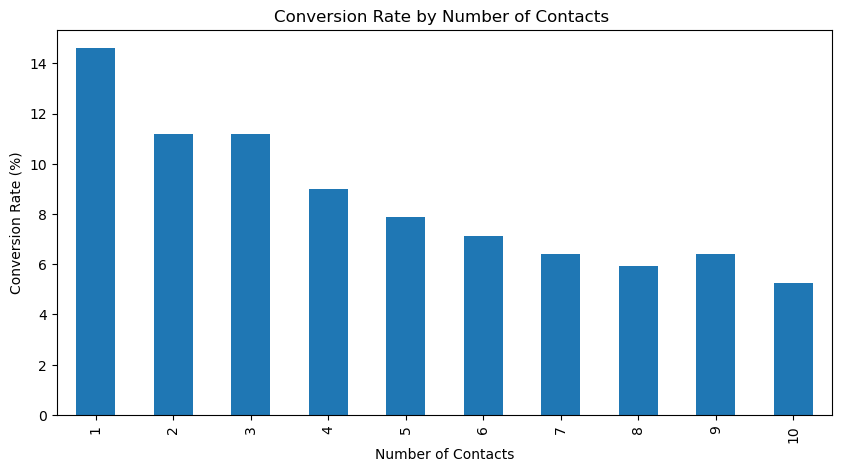

In [102]:
plt.figure(figsize=(10,5))

campaign_analysis.head(10).plot(kind='bar')
plt.title("Conversion Rate by Number of Contacts ")
plt.ylabel("Conversion Rate (%)")
plt.xlabel("Number of Contacts")
plt.show()

## Final Business Insights

### Key Findings

1. The overall conversion rate is 11.7%, indicating that a large percentage of leads do not convert into customers.

2. Students (28.7%) and retired customers (22.8%) have the highest conversion rates among all job categories.

3. Customers with tertiary education demonstrate the strongest conversion performance compared to other education levels.

4. Single customers convert more frequently than married or divorced customers.

5. Campaigns conducted during March, September, October, and December achieved significantly higher conversion rates than other months.

6. Cellular communication is the most effective contact method, while unknown contact channels show poor performance.

7. Customers without housing loans and personal loans are more likely to subscribe to a term deposit.

8. Previous campaign success is the strongest predictor of future conversion, with a conversion rate exceeding 64%.

9. Conversion rates decrease as the number of contact attempts increases, suggesting that early engagement is critical for success.

10. A large drop-off rate of 88.3% indicates opportunities to improve lead qualification and campaign targeting.

## Recommendations

### Business Recommendations

1. Prioritize marketing efforts toward student and retired customer segments, as they show the highest likelihood of conversion.

2. Increase campaign focus on customers with tertiary education and strong financial profiles.

3. Allocate more marketing resources during high-performing months such as March, September, October, and December.

4. Use cellular communication as the primary customer outreach channel.

5. Develop targeted offers for customers without existing housing or personal loans.

6. Re-engage customers who responded positively to previous campaigns, as they represent high-value prospects.

7. Limit excessive follow-up attempts and focus on improving the quality of the first few customer interactions.

8. Implement lead scoring and segmentation strategies to reduce drop-offs and improve overall conversion efficiency.